In [76]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [77]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Currently using {DEVICE}")

Currently using cuda


In [78]:
from src.data_import import load_fashion_mnist, load_mnist_digit, load_CIFAR10, load_olivetti

train_loader, test_loader = load_olivetti(2, shuffle=True)

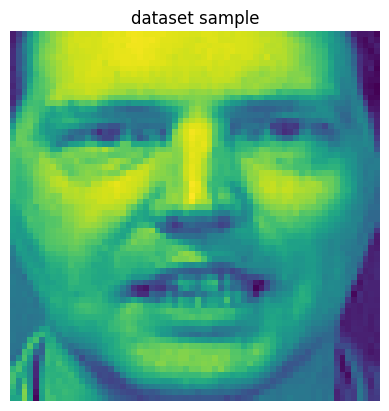

label: 37
shape: torch.Size([2, 1, 64, 64])


In [79]:
from src.plot import show_single_sample, show_grid

x_real, _ = next(iter(train_loader))
show_single_sample(x_real[0], "dataset sample", cmap="viridis")
#print label
print("label:", _[0].item())
print("shape:", x_real.shape)

In [80]:
from src.model import EnergyHead, EBM, SmallEBM

n_heads = 3
IMAGE_SHAPE = (1, 64, 64)

model = EBM(image_shape=IMAGE_SHAPE, mid_dim=150, n_heads=n_heads, batch_size=32)
for head in model.heads:
    head.to(DEVICE)

model.to(DEVICE)

EBM(
  (heads): ModuleList(
    (0-2): 3 x EnergyHead(
      (conv): Sequential(
        (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GELU(approximate='none')
        (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (3): GELU(approximate='none')
        (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (5): GELU(approximate='none')
      )
      (fc): Sequential(
        (0): Linear(in_features=16384, out_features=49, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=49, out_features=1, bias=True)
      )
    )
  )
)

In [81]:
from src.sampler import ReplaySampler
from src.information import TotalCorrelationEstimator

sampler = ReplaySampler(model, img_shape=IMAGE_SHAPE, buffer_size=600, noise_fraction=0.05, device=DEVICE)
total_correlation_estimator = TotalCorrelationEstimator(n_heads, hidden_dim=64)
total_correlation_estimator.to(DEVICE)

In [ ]:
from src.train import train_one_epoch_TC, train_one_epoch
#torch.autograd.set_detect_anomaly(True, check_nan=False)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, betas=(0.0, 0.999))

for epoch in range(32):
    epoch_loss = train_one_epoch(
        model, 
        sampler, 
        train_loader, 
        optimizer,
        sample_steps=40,
        sample_step_size=10.0,
        sample_noise_std=0.005,
        energy_reg=1e-1,
        corr_param=1e-2,
        device=DEVICE

    )
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

  0%|          | 0/140 [00:00<?, ?it/s]

100%|██████████| 140/140 [00:29<00:00,  4.75it/s]


  CD:     -0.0176
  Reg:    0.0338
  Corr:   0.0133
  E_real: -0.0438
  E_fake: -0.0314
  Gap:    -0.0123
Epoch 1, Loss: 0.0295


100%|██████████| 140/140 [00:29<00:00,  4.73it/s]


  CD:     -0.0047
  Reg:    0.0058
  Corr:   0.0133
  E_real: -0.0119
  E_fake: -0.0073
  Gap:    -0.0046
Epoch 2, Loss: 0.0144


...

100%|██████████| 140/140 [00:29<00:00,  4.75it/s]


  CD:     0.0019
  Reg:    0.0005
  Corr:   0.0133
  E_real: 0.0008
  E_fake: -0.0012
  Gap:    0.0020
Epoch 12, Loss: 0.0157


100%|██████████| 140/140 [00:29<00:00,  4.74it/s]


  CD:     0.0003
  Reg:    0.0005
  Corr:   0.0133
  E_real: -0.0002
  E_fake: -0.0006
  Gap:    0.0004
Epoch 13, Loss: 0.0141


 44%|████▎     | 61/140 [00:13<00:17,  4.51it/s]

EBM DIAGNOSTICS

[1] Energy on real data
  Train  →  mean=0.0067,  std=0.0067
  Test   →  mean=0.0064,  std=0.0063
  |E_test - E_train| = 0.0002  (ok)

[2] Energy on fake data (Langevin samples)
  Fake   →  mean=0.0044,  std=0.0077
  Gap (E_real_train - E_fake) = 0.0022  (WARNING: gap inverted)

[3] Energy on pure noise
  Noise  →  mean=4.3170,  std=0.1089
  Gap (E_real_train - E_noise) = -4.3104  (ok)

[4] Per-head energy (on train batch)
  Head 0  →  mean=-0.2149,  std=0.0065
  Head 1  →  mean=-0.0305,  std=0.0015
  Head 2  →  mean=0.0647,  std=0.0009
  Head 3  →  mean=0.1890,  std=0.0016
  Max off-diagonal correlation: 0.9777  (WARNING: heads are correlated)

[5] Replay buffer
  Buffer size: 600 / 600
  Buffer samples  →  mean=0.5429,  std=0.1678,  min=-0.6451,  max=1.0000

[6] Visual samples (Langevin from noise)


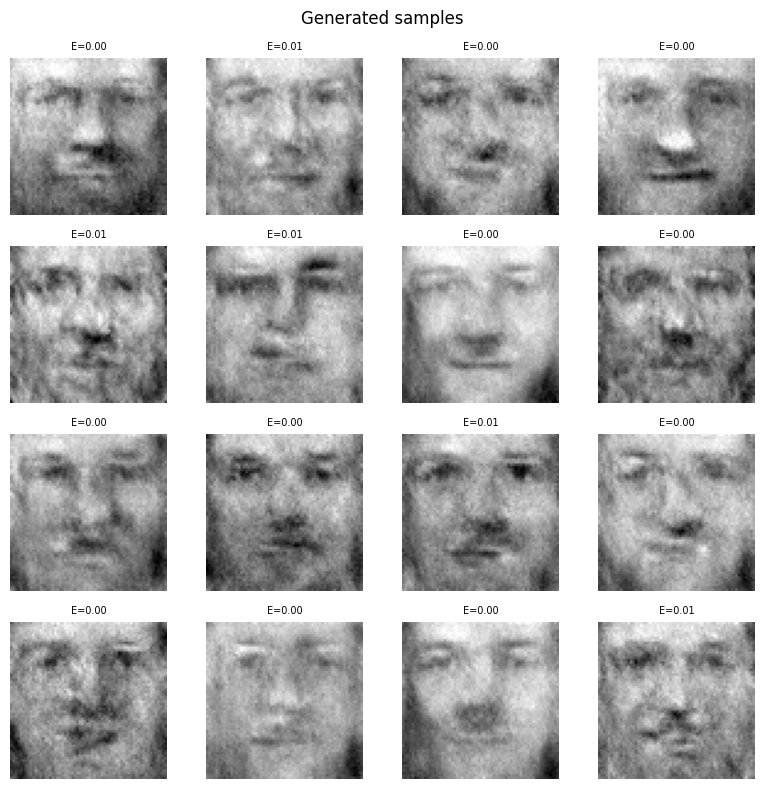


DONE


In [ ]:
from src.diagnostic import diagnose

diagnose(model, sampler, IMAGE_SHAPE, train_loader, test_loader, device=DEVICE, n_samples=16)

In [ ]:
samples = sampler.generate(10, steps=600, step_size=10.0, noise_std=0.005)

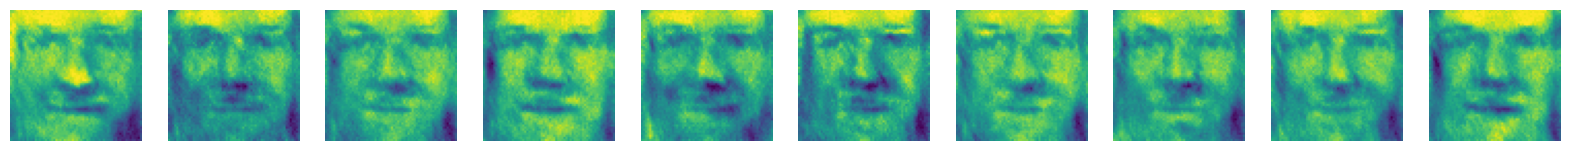

In [ ]:
show_grid(samples, 10)

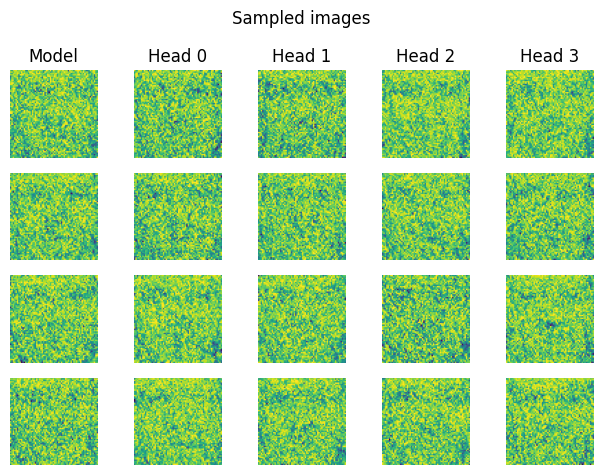

In [ ]:
from src.plot import visualize_heads

fig = visualize_heads(model, sampler.buffer, IMAGE_SHAPE, DEVICE, k=4, cmap="viridis")

In [ ]:
def visualize_head_gradients(model, x, device, idx=0):
    """
    Per una singola immagine, mostra dE_i/dx per ogni testa.
    Rivela cosa "guarda" ogni testa nell'immagine.
    """
    model.eval()
    img = x[idx].unsqueeze(0).to(device)  # (1, 1, 28, 28)

    n_heads = len(model.heads)
    fig, axes = plt.subplots(1, n_heads + 1, figsize=(3 * (n_heads + 1), 3))

    # Immagine originale
    axes[0].imshow(img.squeeze().cpu().numpy(), cmap="gray")
    axes[0].set_title("Input")
    axes[0].axis("off")

    for i, head in enumerate(model.heads):
        x_ = img.detach().requires_grad_(True)
        with torch.enable_grad():
            e = head(x_).sum()
            g = torch.autograd.grad(e, x_, only_inputs=True)[0]

        g_np = g.squeeze().cpu().detach().numpy()
        g_np = np.abs(g_np)
        g_np = (g_np - g_np.min()) / (g_np.max() - g_np.min() + 1e-8)

        axes[i + 1].imshow(g_np, cmap="hot")
        axes[i + 1].set_title(f"Head {i}\n|dE/dx|")
        axes[i + 1].axis("off")

    plt.suptitle("Gradient maps per testa", fontsize=12)
    plt.tight_layout()
    plt.show()

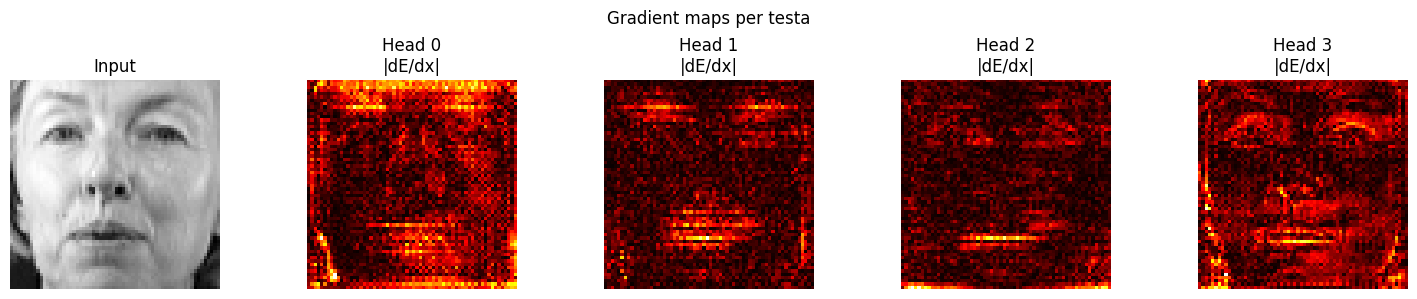

In [ ]:
it = iter(test_loader)
for _ in range(2):
    it.__next__()
x0 = it.__next__()[0]

visualize_head_gradients(model, x0, DEVICE)
